# Persona Effects

Personas influence oracle outcomes at **three levels**:

1. **Plant selection** — each persona has a `selection` strategy (e.g. `oracle_positive`, `niche`, `climate_bias`, `diversity`) that biases *which* plants they receive.
2. **Portfolio size** — `plants_min`/`plants_max` per persona controls how many plants a user gets, feeding into the overload penalty.
3. **Survival bonus** — a flat `survival_bonus` (all negative) is added to `survival_prob` inside `compute_label`.

**Hypothesis:** Survival rates should vary significantly across personas, matching the oracle's design. The model should assign lower scores to user-plant pairs from low-survival personas, even though persona identity isn't directly in the embedding.

## 1. Setup

In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "resources").exists():
    for c in [ROOT.parent, ROOT.parent.parent, ROOT.parent.parent.parent]:
        if (c / "resources").exists():
            ROOT = c
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INTERACTIONS_PATH = ROOT / "resources" / "data" / "synthetic_interactions.json"
USERS_PATH = ROOT / "resources" / "data" / "synthetic_users.json"
PLANTS_PATH = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_normalized.json"
PLANTS_ALT = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_uniform.json"
PERSONA_CFG_PATH = ROOT / "resources" / "synthetic_user" / "persona_interactions.json"
OUTPUT_DIR = ROOT / "resources" / "verify" / "persona effects"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Data

In [2]:
def load_data():
    with open(INTERACTIONS_PATH) as f:
        interactions = json.load(f)
    with open(USERS_PATH) as f:
        users = json.load(f)
    path = PLANTS_PATH if PLANTS_PATH.exists() else PLANTS_ALT
    with open(path) as f:
        plants = json.load(f).get("plants", [])
    user_by_id = {u["user_id"]: u for u in users}
    plant_by_id = {p.get("id"): p for p in plants if p.get("id") is not None}
    return interactions, user_by_id, plant_by_id

interactions, user_by_id, plant_by_id = load_data()

persona_config = {}
if PERSONA_CFG_PATH.exists():
    with open(PERSONA_CFG_PATH) as f:
        persona_config = json.load(f)

print(f"{len(interactions)} interactions, {len(user_by_id)} users, {len(plant_by_id)} plants")
print(f"{len(persona_config)} persona configs: {sorted(persona_config.keys())}")

11206 interactions, 810 users, 1000 plants
9 persona configs: ['climate_mismatch', 'collector', 'impulsive_buyer', 'nervous_nurturer', 'overconfident_beginner', 'recovering_killer', 'researcher', 'serial_experimenter', 'specialist']


## 3. Group Interactions by Persona

In [3]:
def _norm(val):
    if val is None:
        return None
    return str(val).strip().lower() or None


persona_interactions = defaultdict(list)
for r in interactions:
    user = user_by_id.get(r["user_id"], {})
    persona = _norm(user.get("persona")) or "unknown"
    persona_interactions[persona].append(r)

# Count users per persona
users_per_persona = defaultdict(int)
for u in user_by_id.values():
    persona = _norm(u.get("persona")) or "unknown"
    users_per_persona[persona] += 1

print(f"{'Persona':30s} {'Users':>6s} {'Interactions':>13s}")
print("-" * 52)
for p in sorted(persona_interactions.keys()):
    print(f"{p:30s} {users_per_persona[p]:6d} {len(persona_interactions[p]):13d}")

Persona                         Users  Interactions
----------------------------------------------------
climate_mismatch                   70           842
collector                          70          1814
impulsive_buyer                   100          1480
nervous_nurturer                  100           765
overconfident_beginner            120          2118
recovering_killer                  70           857
researcher                        100           592
serial_experimenter                80          1723
specialist                        100          1015


## 4. Survival Rate by Persona

In [4]:
def survival_by_persona(persona_interactions):
    stats = {}
    for persona, ints in persona_interactions.items():
        labels = [r.get("label", 0) for r in ints]
        n = len(labels)
        stats[persona] = {
            "n": n,
            "survival_rate": sum(labels) / n if n else 0,
            "oracle_bonus": persona_config.get(persona, {}).get("survival_bonus", 0.0),
        }
    return stats

surv_stats = survival_by_persona(persona_interactions)

# Sort by survival rate
sorted_personas = sorted(surv_stats.keys(), key=lambda p: surv_stats[p]["survival_rate"])

print(f"{'Persona':30s} {'Survival':>9s} {'n':>7s} {'Oracle bonus':>13s}")
print("-" * 62)
for p in sorted_personas:
    s = surv_stats[p]
    print(f"{p:30s} {s['survival_rate']:9.3f} {s['n']:7d} {s['oracle_bonus']:+13.2f}")

Persona                         Survival       n  Oracle bonus
--------------------------------------------------------------
collector                          0.442    1814         -0.43
climate_mismatch                   0.442     842         -0.45
overconfident_beginner             0.568    2118         -0.28
impulsive_buyer                    0.576    1480         -0.28
serial_experimenter                0.791    1723         -0.10
recovering_killer                  0.834     857         -0.03
nervous_nurturer                   0.847     765         -0.04
researcher                         0.860     592         -0.12
specialist                         0.887    1015         -0.05


## 5. Plot: Survival Rate by Persona

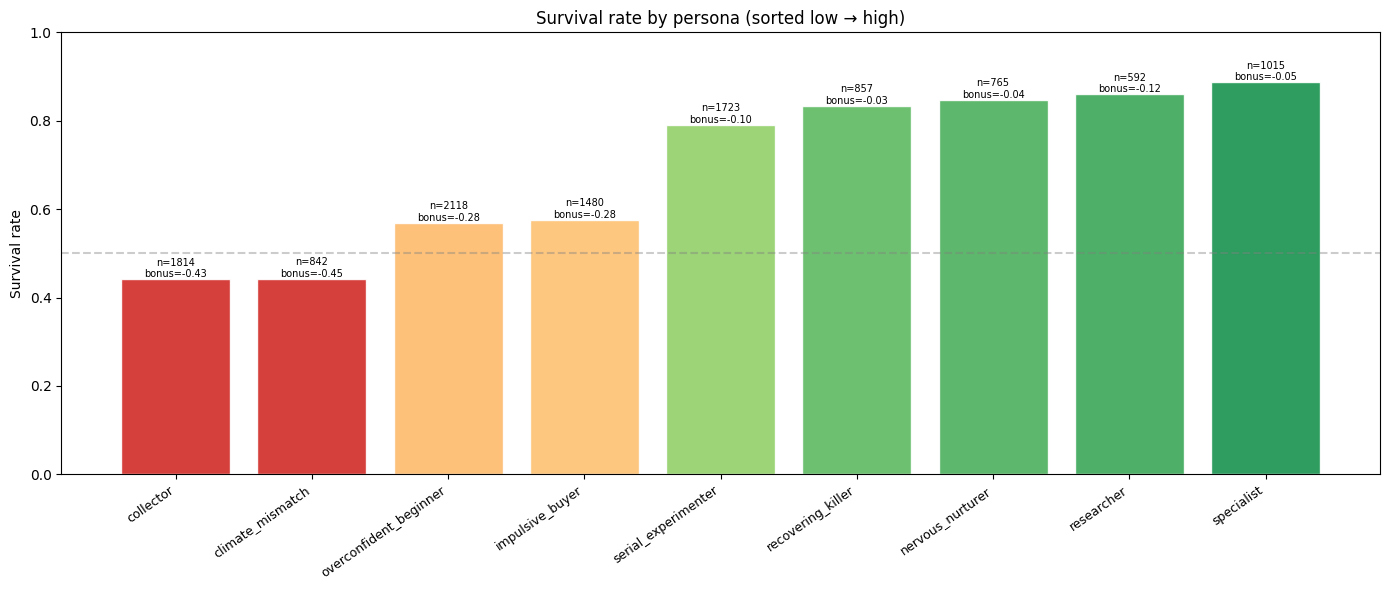

In [5]:
import matplotlib.pyplot as plt
import numpy as np

personas = sorted_personas
surv_vals = [surv_stats[p]["survival_rate"] for p in personas]
surv_n = [surv_stats[p]["n"] for p in personas]
bonus_vals = [surv_stats[p]["oracle_bonus"] for p in personas]

x = np.arange(len(personas))

cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=min(surv_vals) - 0.05, vmax=max(surv_vals) + 0.05)
bar_colors = [cmap(norm(v)) for v in surv_vals]

fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")

bars = ax.bar(x, surv_vals, color=bar_colors, edgecolor="white", alpha=0.9)
for bar, n, bonus in zip(bars, surv_n, bonus_vals):
    ax.annotate(f"n={n}\nbonus={bonus:+.2f}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(personas, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by persona (sorted low → high)")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "persona_survival.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()

## 6. Load Model & Compute Embeddings

In [6]:
import torch
from resources.ETL.feature_engineer import apply_user_embeddings, apply_categorical_embeddings

users_list = list(user_by_id.values())
plants_list = list(plant_by_id.values())
apply_user_embeddings(users_list)
apply_categorical_embeddings(plants_list)
user_by_id = {u["user_id"]: u for u in users_list}
plant_by_id = {p.get("id"): p for p in plants_list}

model = None
for p in [ROOT / "resources" / "two_tower_training" / "two_tower.pt",
          ROOT / "resources" / "two_tower_training" / "output" / "two_tower.pt"]:
    if p.exists():
        ckpt = torch.load(p, map_location="cpu", weights_only=True)
        state = ckpt.get("model_state", ckpt)
        if any("user_tower.mlp" in k for k in state.keys()):
            from resources.two_tower_training.two_tower_model import TwoTowerModel
            model = TwoTowerModel()
            model.load_state_dict(state, strict=True)
            model.eval()
            print(f"Loaded model from {p}")
            break
if model is None:
    print("Model not found — skip model analysis.")

Loaded model from /Users/yemarnaung/Documents/Projects/HowToKeepYourPlantsAlive/resources/two_tower_training/output/two_tower.pt


## 7. Model Scores by Persona

In [7]:
def model_scores_by_persona(persona_interactions, user_by_id, plant_by_id, model):
    results = {}
    for persona, ints in persona_interactions.items():
        batch_u, batch_p = [], []
        for r in ints:
            u = user_by_id.get(r["user_id"], {})
            p = plant_by_id.get(r["plant_id"]) or {}
            if not p or "categorical_embedding" not in p:
                continue
            u_emb = u.get("categorical_embedding")
            if not u_emb or len(u_emb) != 21:
                continue
            batch_u.append(list(u_emb) + [0.0] * 64 + [0.0] * 64)
            batch_p.append(p["categorical_embedding"])

        if not batch_u:
            results[persona] = {"n": 0, "mean_score": 0}
            continue

        u_t = torch.tensor(batch_u, dtype=torch.float32)
        p_t = torch.tensor(batch_p, dtype=torch.float32)
        with torch.no_grad():
            scores = model(u_t, p_t).numpy()
        results[persona] = {"n": len(scores), "mean_score": float(scores.mean())}
    return results

if model:
    model_stats = model_scores_by_persona(persona_interactions, user_by_id, plant_by_id, model)
    print(f"{'Persona':30s} {'Model score':>12s} {'n':>7s}")
    print("-" * 52)
    for p in sorted_personas:
        s = model_stats.get(p, {})
        print(f"{p:30s} {s.get('mean_score', 0):12.4f} {s.get('n', 0):7d}")
else:
    model_stats = None
    print("Model not loaded — skip.")

Persona                         Model score       n
----------------------------------------------------
collector                            4.1258    1814
climate_mismatch                     4.1973     842
overconfident_beginner               3.1841    2118
impulsive_buyer                      3.1725    1480
serial_experimenter                  5.3757    1723
recovering_killer                    4.1307     857
nervous_nurturer                     3.1785     765
researcher                           5.3636     592
specialist                           5.4298    1015


## 8. Plot: Survival + Model Score by Persona (Dual Y-Axis)

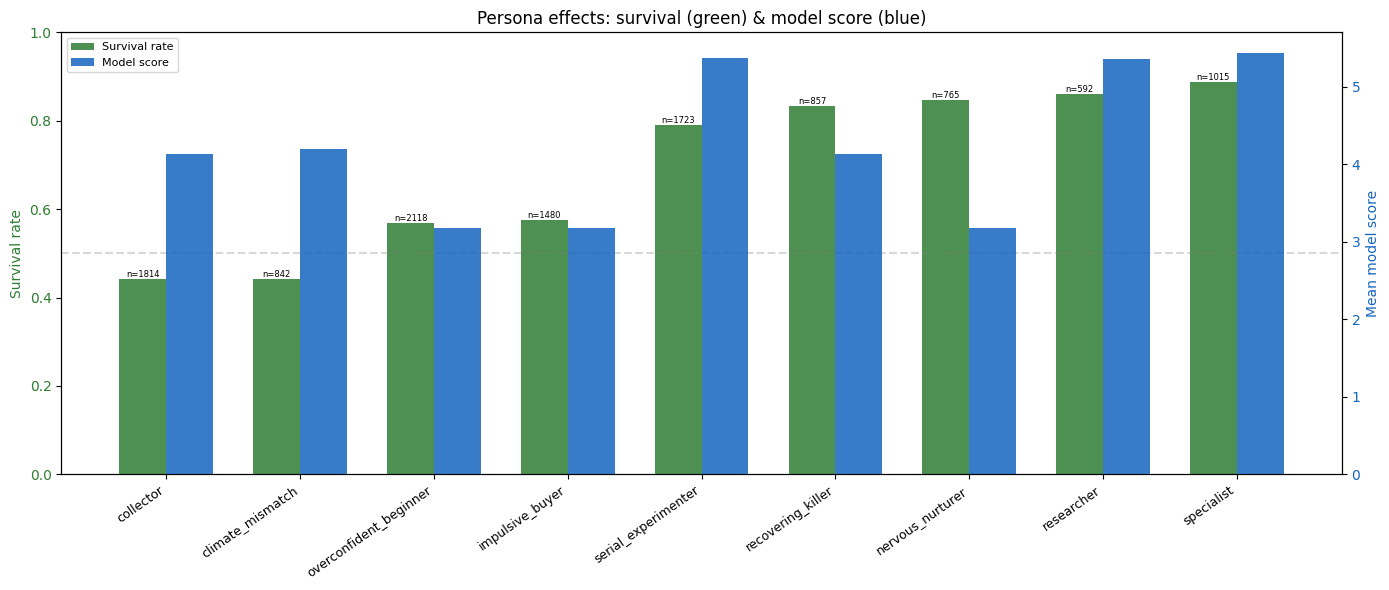

In [8]:
if model_stats:
    personas = sorted_personas
    surv_vals = [surv_stats[p]["survival_rate"] for p in personas]
    model_vals = [model_stats.get(p, {}).get("mean_score", 0) for p in personas]
    n_vals = [surv_stats[p]["n"] for p in personas]

    x = np.arange(len(personas))
    w = 0.35

    fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
    ax_twin = ax.twinx()

    bars_s = ax.bar(x - w / 2, surv_vals, w, color="#2e7d32", alpha=0.85, label="Survival rate")
    bars_m = ax_twin.bar(x + w / 2, model_vals, w, color="#1565c0", alpha=0.85, label="Model score")

    for bar, n in zip(bars_s, n_vals):
        ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(personas, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Survival rate", color="#2e7d32")
    ax_twin.set_ylabel("Mean model score", color="#1565c0")
    ax.tick_params(axis="y", labelcolor="#2e7d32")
    ax_twin.tick_params(axis="y", labelcolor="#1565c0")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.3)
    ax.set_title("Persona effects: survival (green) & model score (blue)")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "persona_model.png", dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("Model not loaded — combined plot skipped.")

## 9. Correlation: Survival vs Model Score

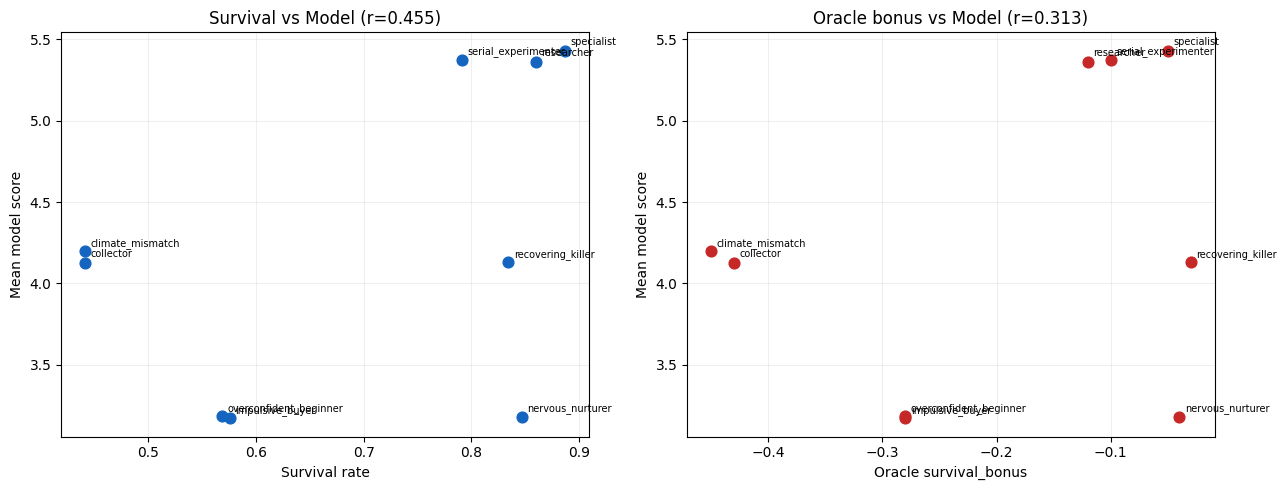

Correlation (survival ↔ model):       r = 0.455
Correlation (oracle_bonus ↔ model):    r = 0.313
Correlation (oracle_bonus ↔ survival): r = 0.977


In [9]:
if model_stats:
    personas = sorted_personas
    s_vals = np.array([surv_stats[p]["survival_rate"] for p in personas])
    m_vals = np.array([model_stats.get(p, {}).get("mean_score", 0) for p in personas])
    bonus_vals = np.array([surv_stats[p]["oracle_bonus"] for p in personas])

    corr_sm = np.corrcoef(s_vals, m_vals)[0, 1]
    corr_bm = np.corrcoef(bonus_vals, m_vals)[0, 1]
    corr_bs = np.corrcoef(bonus_vals, s_vals)[0, 1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")

    ax1 = axes[0]
    ax1.scatter(s_vals, m_vals, c="#1565c0", s=60, zorder=3)
    for i, p in enumerate(personas):
        ax1.annotate(p, (s_vals[i], m_vals[i]), fontsize=7, ha="left",
                     xytext=(4, 4), textcoords="offset points")
    ax1.set_xlabel("Survival rate")
    ax1.set_ylabel("Mean model score")
    ax1.set_title(f"Survival vs Model (r={corr_sm:.3f})")
    ax1.grid(alpha=0.2)

    ax2 = axes[1]
    ax2.scatter(bonus_vals, m_vals, c="#c62828", s=60, zorder=3)
    for i, p in enumerate(personas):
        ax2.annotate(p, (bonus_vals[i], m_vals[i]), fontsize=7, ha="left",
                     xytext=(4, 4), textcoords="offset points")
    ax2.set_xlabel("Oracle survival_bonus")
    ax2.set_ylabel("Mean model score")
    ax2.set_title(f"Oracle bonus vs Model (r={corr_bm:.3f})")
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "persona_correlation.png", dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"Correlation (survival ↔ model):       r = {corr_sm:.3f}")
    print(f"Correlation (oracle_bonus ↔ model):    r = {corr_bm:.3f}")
    print(f"Correlation (oracle_bonus ↔ survival): r = {corr_bs:.3f}")
else:
    print("Model not loaded — correlation skipped.")

## 10. Summary

- **Oracle design:** Each persona has a `survival_bonus` (ranging from -0.03 to -0.45) plus indirect effects from plant selection bias and portfolio size.
- **Expected survival ranking** (worst → best): `climate_mismatch` < `collector` < `overconfident_beginner` ≈ `impulsive_buyer` < `researcher` < `serial_experimenter` < `specialist` < `nervous_nurturer` ≈ `recovering_killer`.
- **Model signal:** The model doesn't see persona labels directly — it must infer persona-like patterns from the user embedding (categorical features + aggregate embeddings). A positive survival ↔ model correlation means the model is picking up persona-level effects.
- **Key question:** Is the correlation strong (model has learned persona patterns) or weak (persona effects are too subtle / confounded by other features)?